# Validation 3 — Semi-Analytical Kernel & RL Pricer

We replace the single-sample TD bootstrap in D4PG with a **deterministic quadrature target**:

$$Q_{\text{target}}(s,a)\;=\;r(s,a)\;+\;\mathbb{E}\!\left[Q(s',\pi(s'))\mid s,a\right],$$

where the expectation is evaluated analytically over the **HHK one-step transition kernel**
(Gauss–Hermite on the OU factor $\times$ compound-Poisson jump mesh).

**Outline.**
- **Part I** — *Is the quadrature correct?* Spectral convergence, nested-MC agreement, cost/accuracy frontier.
- **Part II** — *Does the RL policy price well?* Three pricers, **8 estimators each**, all evaluated on the **same 8 out-of-sample 65 536-path sets**; mean ± std by **1000-resample bootstrap**:
  - **LSM-D** — full-state Chebyshev deg-2 ($M{=}5$)
  - **RL no kernel** (v67) — single-sample TD, 4 096 ep
  - **RL kernel** (v67) — analytic expected backup ($M_x{=}2$), 4 096 ep

*Regimes:* no-cost ($c{=}0,\gamma{=}1$) and $c{=}0.04$ at $\gamma\in\{1,1.5,2\}$ (focal $\gamma{=}2$).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

# --- locate companion folder (CSVs) and repo (for stats_analysis) ---
NB_DIR = Path.cwd()
D = NB_DIR / "3: Validation 3: Semi-Analytical Kernel & RL Pricer"
if not (D / "kernel_moments.csv").exists():
    D = Path("3: Validation 3: Semi-Analytical Kernel & RL Pricer")
ROOT = (D.resolve().parents[1])
FIGS = D / "figs"; FIGS.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT))           # repo root — needed for `from src.*` imports (e.g. F6)
sys.path.insert(0, str(ROOT / "tools"))
import stats_analysis as sa   # Welch / Levene / F-ratio / MDE

# --- house style: clean, publication-grade ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9.5, "axes.edgecolor": "#444",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
COL = {"kernel_on": "#0b7285", "kernel_off": "#d6336c",
       "lsm_M5": "#c0c6cc", "lsm_M9": "#7b848c", "lsm_M17": "#2b2f33",
       "accent": "#e8590c", "ok": "#2b8a3e"}
REG_LABEL = {"nocost": r"no cost ($\gamma$=1)", "g1": r"$c$=0.04, $\gamma$=1",
             "g15": r"$c$=0.04, $\gamma$=1.5", "g2": r"$c$=0.04, $\gamma$=2 (focal)"}
REG_ORDER = ["nocost", "g1", "g15", "g2"]

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png"); fig.savefig(FIGS / f"{name}.pdf")

# --- load everything ---
KM  = pd.read_csv(D / "kernel_moments.csv")
KQ  = pd.read_csv(D / "kernel_quadrature_convergence.csv")
KJ  = pd.read_csv(D / "kernel_jump_mesh_convergence.csv")
KN  = pd.read_csv(D / "kernel_nested_mc_agreement.csv")
KC  = pd.read_csv(D / "kernel_cost_accuracy.csv")
RL  = pd.read_csv(D / "rl_lsm_pricing.csv")
EE  = pd.read_csv(D / "episode_efficiency.csv")
MX  = pd.read_csv(D / "mx_isolation.csv")
print("Loaded:", {k: v.shape for k, v in
      dict(moments=KM, quad=KQ, jump=KJ, nested=KN, cost=KC,
           pricing=RL, episodes=EE, mx=MX).items()})

def boot(x, n_boot=1000, seed=0):
    """Bootstrap mean and std of the sampling distribution of the mean (1000 resamples)."""
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan"), float("nan")
    means = np.random.default_rng(seed).choice(x, (n_boot, len(x)), replace=True).mean(1)
    return float(x.mean()), float(means.std())


Loaded: {'moments': (19, 7), 'quad': (168, 9), 'jump': (44, 12), 'nested': (72, 10), 'cost': (6, 9), 'pricing': (160, 6), 'episodes': (72, 4), 'mx': (27, 8)}


---
# Part I · Mathematics of the HHK transition kernel

Under $S_t=\exp(f(t)+X_t+Y_t)$ with OU diffusion $dX=-\alpha X\,dt+\sigma\,dW$ and compound-Poisson
jumps $dY=-\beta Y\,dt+J\,dN$, the one-step transition factorises into an **exact Gaussian leg**
and a **jump leg**. The kernel uses $M_x$ Gauss–Hermite nodes on $X'$ and a stratified-QMC mesh on
$Y'$; total node count $M=M_x(1+N_{\max}M_{\text{per }k})$.

- **FAST** $(M_x{=}2,\,M_{\text{per }k}{=}1,\,N_{\max}{=}1)\Rightarrow M{=}4$ — production kernel
- **ACCURATE** $(M_x{=}4,\,M_{\text{per }k}{=}4,\,N_{\max}{=}2)\Rightarrow M{=}36$ — convergence reference

#### How the mesh is chosen

- **OU leg ($M_x$ Gauss–Hermite nodes):** The integrand is smooth against a Gaussian density $\Rightarrow$ spectral convergence; $M_x{=}1$ collapses (point mass), $M_x{\ge}2$ is fully converged (F1–F2, R5). $M_x$ is the sole controlling axis.
- **Jump leg ($N_{\max}$, $M_{\text{per }k}$):** Compound-Poisson sum with $\lambda\Delta t\approx0.029$, so ${\ge}97\%$ mass on $k{=}0$. $N_{\max}{=}1$–$2$ drives the truncation tail below the Gaussian-leg floor; $M_{\text{per }k}$ barely matters once ${\ge}1$.

### F1 · OU/Gaussian leg — spectral convergence

With $\lambda{=}0$ the transition is purely Gaussian; the conditional moments $\mathbb{E}[S_{t+1}\mid X_t]$ and $\mathbb{E}[S_{t+1}^2\mid X_t]$ have closed forms (OU MGF). Gauss–Hermite quadrature should converge spectrally in $M_x$.

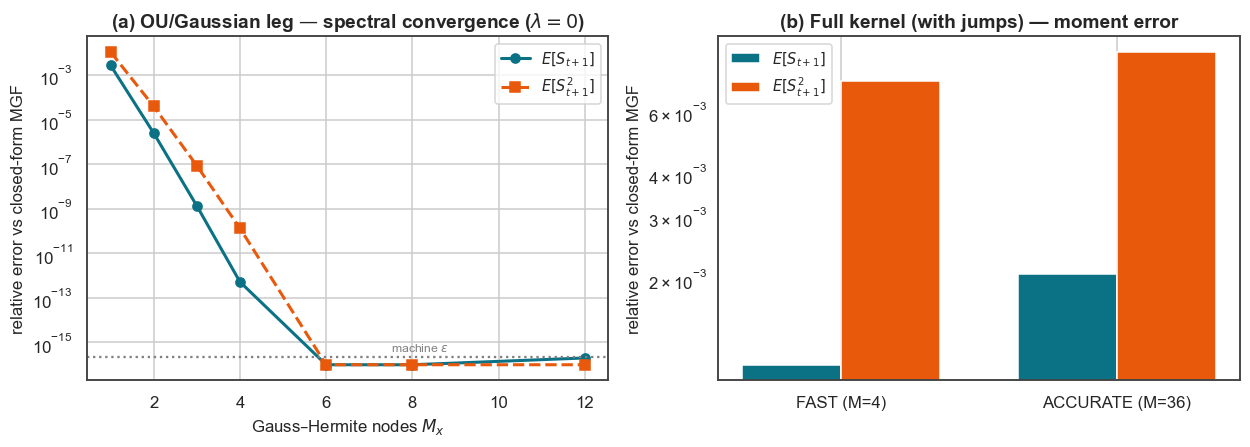

Gaussian leg reaches machine precision by M_x=4; with jumps the error settles at the jump-mesh floor (~1e-3 on E[S]) — the subject of F2/F3.


In [2]:
g = KM[KM.leg == "gaussian"].sort_values("M_x")
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].semilogy(g.M_x, g.relerr_ES.clip(1e-16), "o-", color=COL["kernel_on"], lw=2, label=r"$E[S_{t+1}]$")
ax[0].semilogy(g.M_x, g.relerr_ES2.clip(1e-16), "s--", color=COL["accent"], lw=2, label=r"$E[S_{t+1}^2]$")
ax[0].axhline(2.2e-16, ls=":", color="grey"); ax[0].text(7.5, 4e-16, "machine $\\epsilon$", color="grey", fontsize=8)
ax[0].set(xlabel=r"Gauss–Hermite nodes $M_x$", ylabel="relative error vs closed-form MGF",
          title="(a) OU/Gaussian leg — spectral convergence ($\\lambda=0$)")
ax[0].legend(frameon=True)

f = KM[KM.leg.str.startswith("full")].groupby("leg")[["relerr_ES", "relerr_ES2"]].first()
f = f.reindex(["full_fast", "full_accurate"])
x = np.arange(2); w = 0.36
ax[1].bar(x - w/2, f.relerr_ES, w, color=COL["kernel_on"], label=r"$E[S_{t+1}]$")
ax[1].bar(x + w/2, f.relerr_ES2, w, color=COL["accent"], label=r"$E[S_{t+1}^2]$")
ax[1].set_yscale("log"); ax[1].set_xticks(x, ["FAST (M=4)", "ACCURATE (M=36)"])
ax[1].set(ylabel="relative error vs closed-form MGF",
          title="(b) Full kernel (with jumps) — moment error")
ax[1].legend(frameon=True)
fig.tight_layout(); save(fig, "F1_gaussian_leg"); plt.show()
print("Gaussian leg reaches machine precision by M_x=4; with jumps the error settles at the "
      "jump-mesh floor (~1e-3 on E[S]) — the subject of F2/F3.")

### F2 · Full-kernel convergence in $M_x$ vs nested Monte-Carlo

Full kernel expectation vs a 2M-path nested MC reference for $E[S]$, $E[S^2]$, $E[(S{-}K)^+]$, and a smooth payoff proxy, as $M_x$ increases (jump mesh held at ACCURATE). The curve should plateau at the jump-mesh floor once $M_x{\ge}2$.

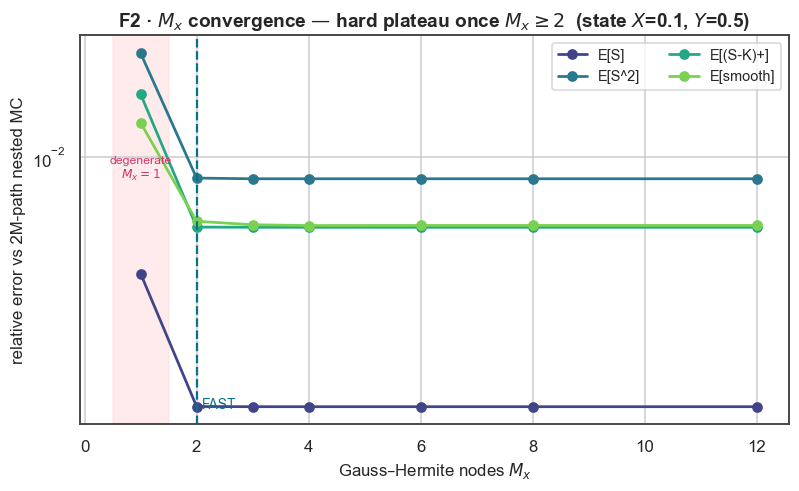

In [3]:
qs = KQ[(KQ.X == 0.10) & (KQ.Y == 0.50)]
order = ["E[S]", "E[S^2]", "E[(S-K)+]", "E[smooth]"]
cmap = dict(zip(order, sns.color_palette("viridis", 4)))
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for fn in order:
    d = qs[qs.func == fn].sort_values("M_x")
    ax.semilogy(d.M_x, d.relerr, "o-", lw=1.8, color=cmap[fn], label=fn)
ax.axvspan(0.5, 1.5, color="#ffe3e3", alpha=.7, zorder=0)
ax.text(1.0, ax.get_ylim()[1]*0.4, "degenerate\n$M_x=1$", ha="center", color=COL["kernel_off"], fontsize=8)
ax.axvline(2, ls="--", color=COL["kernel_on"]); ax.text(2.1, 2e-3, "FAST", color=COL["kernel_on"], fontsize=9)
ax.set(xlabel=r"Gauss–Hermite nodes $M_x$", ylabel="relative error vs 2M-path nested MC",
       title="F2 · $M_x$ convergence — hard plateau once $M_x\\geq2$  (state $X$=0.1, $Y$=0.5)")
ax.legend(frameon=True, ncol=2)
fig.tight_layout(); save(fig, "F2_Mx_convergence"); plt.show()

### F3 · Jump-mesh convergence

Residual error from F2 is the jump-mesh discretisation, controlled by Poisson truncation $N_{\max}$ and per-count QMC resolution $M_{\text{per }k}$. Since $\lambda\Delta t\approx0.029$, the tail beyond $N_{\max}{=}2$ is negligible.

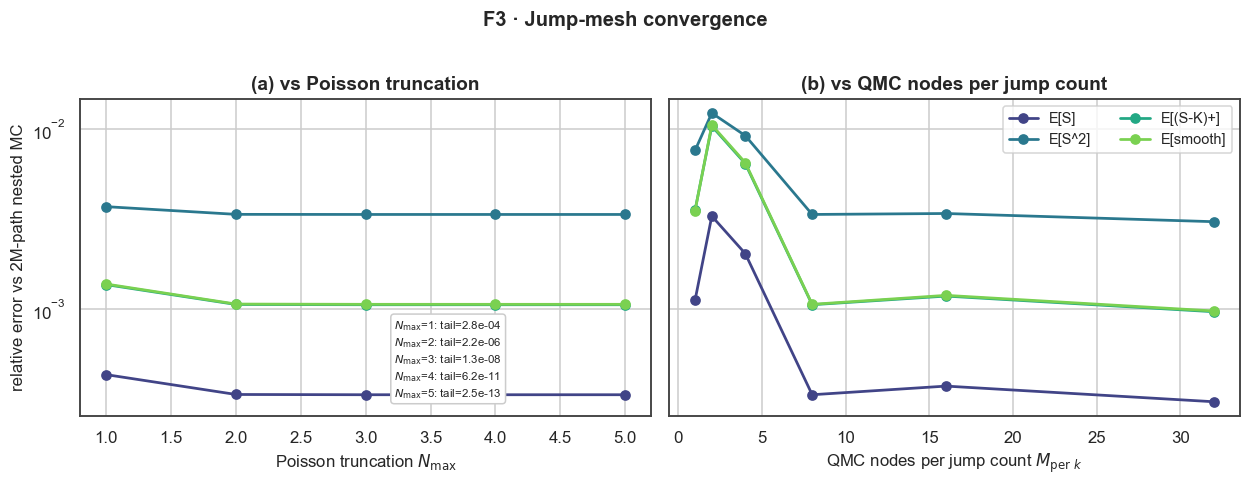

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
order = ["E[S]", "E[S^2]", "E[(S-K)+]", "E[smooth]"]
cmap = dict(zip(order, sns.color_palette("viridis", 4)))
for a, axis, xl in [(ax[0], "N_max", r"Poisson truncation $N_{\max}$"),
                    (ax[1], "M_per_k", r"QMC nodes per jump count $M_{\text{per }k}$")]:
    s = KJ[KJ.axis == axis]
    for fn in order:
        d = s[s.func == fn].sort_values("value")
        a.semilogy(d.value, d.relerr, "o-", lw=1.8, color=cmap[fn], label=fn)
    a.set(xlabel=xl, title=f"({'a' if axis=='N_max' else 'b'}) vs {xl.split('$')[0].strip()}")
ax[0].set_ylabel("relative error vs 2M-path nested MC")
tail = KJ[(KJ.axis == "N_max")].groupby("value").poisson_tail.first()
ax[0].text(0.55, 0.05, "\n".join(f"$N_{{\\max}}$={int(k)}: tail={v:.1e}" for k, v in tail.items()),
           transform=ax[0].transAxes, fontsize=7.5, va="bottom",
           bbox=dict(boxstyle="round", fc="white", ec="#ccc"))
ax[1].legend(frameon=True, ncol=2)
fig.suptitle("F3 · Jump-mesh convergence", fontweight="bold", y=1.02)
fig.tight_layout(); save(fig, "F3_jump_mesh"); plt.show()

### F4 · Agreement with nested Monte-Carlo for fixed state–action pairs

For fixed states we compare the deterministic kernel target against a 4M-path nested-MC gold reference, for payoff integrands and the **actual critic network** $Q(s',\pi(s'))$. **(a)** Kernel bias is sub-percent at every mesh setting; **(b)** that bias is 6–120$\times$ smaller than the single-sample bootstrap noise it replaces.

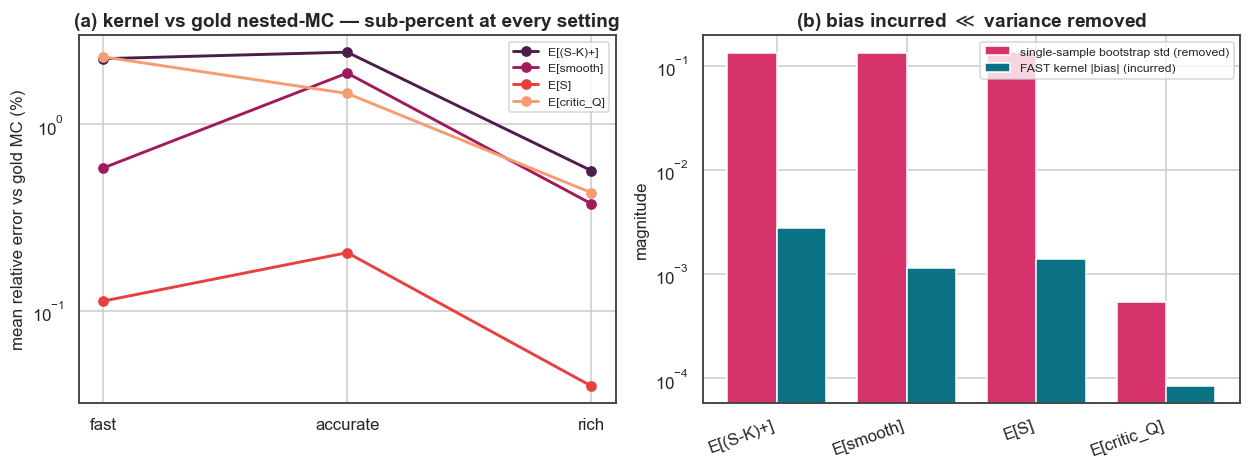

FAST kernel: single-sample noise / kernel bias ≈ 6–118× across integrands (the variance-reduction factor of the expected backup).


In [5]:
# keep states whose option payoff is non-negligible (deep-OTM states have vanishing
# denominators that blow up relative error); applied at the STATE level so every
# integrand -- including the small-magnitude critic Q -- is retained.
pay = KN[KN.func == "E[(S-K)+]"].groupby(["X", "Y"]).mc_ref.first()
itm_xy = set(pay[pay > 0.05].index)
KN["_xy"] = list(zip(KN.X, KN.Y))
itm = KN[KN["_xy"].isin(itm_xy)].copy()
itm["abs_err"] = (itm.kernel - itm.mc_ref).abs()
tier_order = ["fast", "accurate", "rich"]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
# (a) rel-error convergence across tiers (mean over ITM states), per function
funcs = ["E[(S-K)+]", "E[smooth]", "E[S]", "E[critic_Q]"]
cmap = dict(zip(funcs, sns.color_palette("rocket", 4)))
for fn in funcs:
    d = itm[itm.func == fn].groupby("kernel_tag").rel_err.mean().reindex(tier_order)
    ax[0].plot(tier_order, 100*d.values, "o-", lw=1.9, color=cmap[fn], label=fn)
ax[0].set(ylabel="mean relative error vs gold MC (%)",
          title="(a) kernel vs gold nested-MC — sub-percent at every setting")
ax[0].set_yscale("log"); ax[0].legend(frameon=True, fontsize=8)

# (b) variance reduction: deterministic kernel bias vs single-sample bootstrap noise
d = itm[itm.kernel_tag == "fast"].groupby("func").agg(abs_err=("abs_err", "mean"),
                                                      boot=("boot_std", "mean")).reindex(funcs)
x = np.arange(len(funcs)); w = 0.38
ax[1].bar(x - w/2, d.boot, w, color=COL["kernel_off"], label="single-sample bootstrap std (removed)")
ax[1].bar(x + w/2, d.abs_err, w, color=COL["kernel_on"], label="FAST kernel |bias| (incurred)")
ax[1].set_yscale("log"); ax[1].set_xticks(x, funcs, rotation=20, ha="right")
ax[1].set(ylabel="magnitude", title=r"(b) bias incurred $\ll$ variance removed")
ax[1].legend(frameon=True, fontsize=8)
fig.tight_layout(); save(fig, "F4_nested_mc"); plt.show()

ratio = (d.boot / d.abs_err).replace([np.inf], np.nan).dropna()
print(f"FAST kernel: single-sample noise / kernel bias ≈ {ratio.min():.0f}–{ratio.max():.0f}× "
      "across integrands (the variance-reduction factor of the expected backup).")

### F5 · Cost / accuracy frontier

Per-call build time ($B{=}128$ batch) vs accuracy on the smooth continuation integrand. The FAST $M{=}4$ kernel sits at the Pareto knee — sub-percent error at a few microseconds.

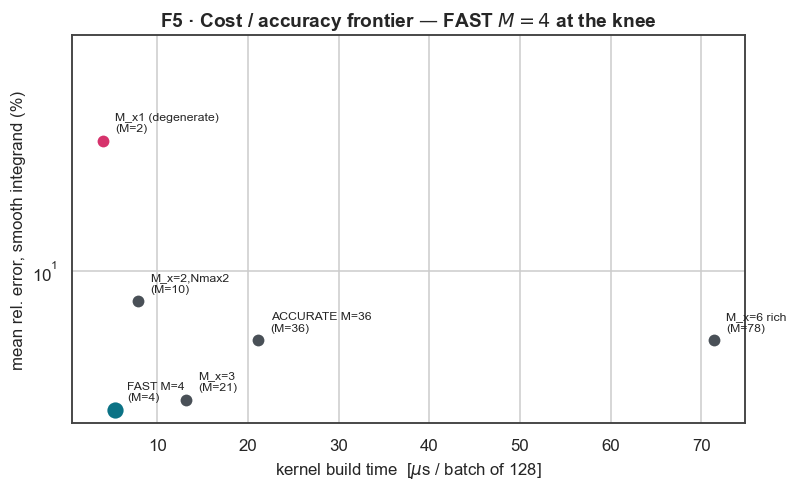

,label,M,relerr_ES,relerr_smooth,worst_relerr,build_us_b128
0,M_x1 (degenerate),2,0.00386,0.3058,0.842,4.0
1,FAST M=4,4,0.00115,0.0303,0.600,5.4
2,"M_x=2,Nmax2",10,0.00332,0.0771,0.761,7.8
3,M_x=3,21,0.00120,0.0331,0.247,13.2
4,ACCURATE M=36,36,0.00207,0.0551,0.210,21.2
5,M_x=6 rich,78,0.00207,0.0550,0.144,71.4


In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for _, r in KC.iterrows():
    is_fast = r.label.startswith("FAST"); is_deg = r.M_x == 1
    c = COL["kernel_on"] if is_fast else (COL["kernel_off"] if is_deg else "#495057")
    ax.scatter(r.build_us_b128, 100*r.relerr_smooth, s=140 if is_fast else 80, color=c, zorder=3,
               edgecolor="white", linewidth=1.2)
    ax.annotate(f"{r.label}\n(M={int(r.M)})", (r.build_us_b128, 100*r.relerr_smooth),
                textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set_yscale("log")
ax.set_ylim(top=ax.get_ylim()[1] * 2.2)   # headroom so annotations clear the title
ax.set(xlabel=r"kernel build time  [$\mu$s / batch of 128]",
       ylabel="mean rel. error, smooth integrand (%)",
       title="F5 · Cost / accuracy frontier — FAST $M{=}4$ at the knee")
fig.tight_layout(); save(fig, "F5_pareto"); plt.show()
display(KC[["label","M","relerr_ES","relerr_smooth","worst_relerr","build_us_b128"]]
        .round({"relerr_ES":5,"relerr_smooth":4,"worst_relerr":3,"build_us_b128":1}))

### F6 · The quadrature mesh in state space

For a current state $(X_t,Y_t)$ the kernel evaluates the continuation on a **product grid** of next states:

$$X'_i = e^{-\alpha\Delta t}X_t + \sigma_X z_i,\qquad Y'_j = e^{-\beta\Delta t}Y_t + \Delta_j,\qquad w_{ij}=w^X_i w^Y_j.$$

The $M_x$ columns are Gauss–Hermite nodes (OU shock); the rows are jump-increment nodes — one no-jump node plus $M_{\text{per }k}$ QMC nodes per jump count $k=1,\dots,N_{\max}$. The no-jump branch carries $\approx$ 97.6% of the mass.

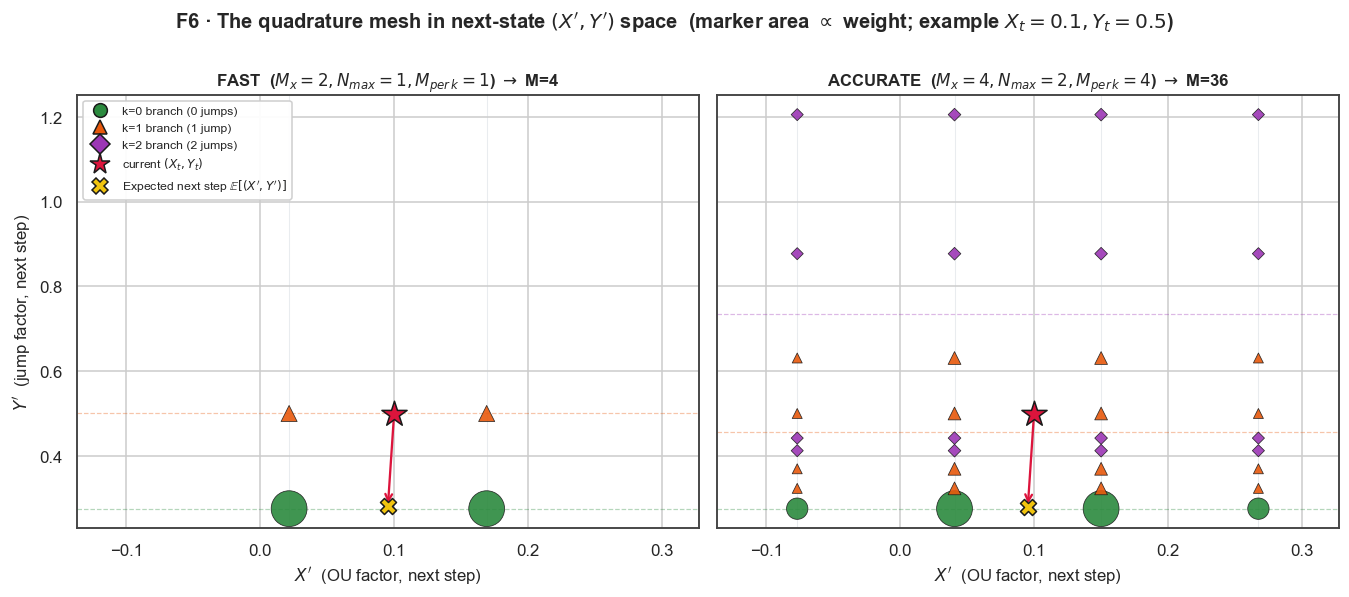

FAST M=4, ACCURATE M=36 | no-jump weight P(0)=0.9765, lambda*dt=0.0238 | sigma_X(FAST)=0.0738, decay_Y=0.5516


In [7]:
# F6 · authentic kernel nodes (built with the production src.transition_kernel API)
from matplotlib.lines import Line2D
from src.transition_kernel import KernelParams, precompute_kernel

# focal HHK contract params (self-contained; matches gen_rl_validation_v67.py mk_params)
ALPHA, SIGMA, BETA, LAM, MU_J = 12.0, 1.2, 150.0, 6.0, 0.3
MAT, NR = 0.0833, 22; DT = MAT / (NR - 1)
P0, LDT = float(np.exp(-LAM * DT)), LAM * DT
Xt, Yt = 0.10, 0.50                     # example current state (matches F2)
KCOL   = {0: "#2b8a3e", 1: "#e8590c", 2: "#9c36b5", 3: "#1971c2"}
KMARKER = {0: "o", 1: "^", 2: "D", 3: "s"}

def _kernel(mx, nmax, mpk):
    kp = KernelParams(alpha=ALPHA, sigma=SIGMA, beta=BETA, lam=LAM, mu_J=MU_J, dt=DT,
                      M_x=mx, N_max=nmax, M_per_k=mpk, f_id="no_seasonal")
    return precompute_kernel(kp, NR, lambda t: 0.0, maturity=MAT, force_rebuild=True), (mx, nmax, mpk)

def _layout(k, cfg):
    mx, nmax, mpk = cfg
    Xp = k.decay_X * Xt + k.sigma_X * k.z_X
    Yp = k.decay_Y * Yt + k.delta_Y
    W  = np.outer(k.w_X, k.w_Y)
    kj = np.array([0] + [1 + (j - 1) // mpk for j in range(1, len(Yp))])
    rows = [(xv, yv, W[i, j], kj[j]) for i, xv in enumerate(Xp) for j, yv in enumerate(Yp)]
    return np.array(rows), Xp, Yp

fast, acc = _kernel(2, 1, 1), _kernel(4, 2, 4)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True, sharey=True)
names = [r"FAST  ($M_x{=}2, N_{max}{=}1, M_{per\,k}{=}1$) $\to$ M=4",
         r"ACCURATE  ($M_x{=}4, N_{max}{=}2, M_{per\,k}{=}4$) $\to$ M=36"]
for ax, (k, cfg), name in zip(axes, [fast, acc], names):
    R, Xp, Yp = _layout(k, cfg)
    x, y, w, kj = R[:, 0], R[:, 1], R[:, 2], R[:, 3].astype(int)
    X_next_avg = np.sum(x * w) / np.sum(w)
    Y_next_avg = np.sum(y * w) / np.sum(w)
    
    for xv in Xp:
        ax.axvline(xv, color="#e9ecef", lw=.7, zorder=0)
    s = 30 + 520 * np.sqrt(w / w.max())
    for kk in sorted(set(kj)):
        m = kj == kk
        ax.scatter(x[m], y[m], s=s[m], c=KCOL[kk], marker=KMARKER[kk], edgecolor="k", lw=.5, alpha=.9, zorder=3)
    ax.scatter([Xt], [Yt], marker="*", s=300, c="crimson", edgecolor="k", zorder=6)
    ax.scatter([X_next_avg], [Y_next_avg], marker="X", s=110, c="#f1c40f", edgecolor="k", zorder=6)
    ax.annotate("", xy=(X_next_avg, Y_next_avg), xytext=(Xt, Yt),
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5, zorder=5))
    
    # Draw dashed lines for branch mean values without any labels
    for kk in sorted(set(kj)):
        yv = y[kj == kk].mean()
        ax.axhline(yv, color=KCOL[kk], lw=0.8, ls="--", alpha=0.35, zorder=1)
        
    ax.set_title(name, fontsize=11)
    ax.set_xlabel(r"$X'$  (OU factor, next step)")

axes[0].set_ylabel(r"$Y'$  (jump factor, next step)")

# xlim: cover the widest X′ range across BOTH kernels so no node is clipped.
_all_xp = np.concatenate([fast[0].decay_X * Xt + fast[0].sigma_X * fast[0].z_X,
                           acc[0].decay_X  * Xt + acc[0].sigma_X  * acc[0].z_X])
axes[0].set_xlim(_all_xp.min() - 0.06, _all_xp.max() + 0.06)

_leg = [Line2D([0], [0], marker=KMARKER[kk], color="w", markerfacecolor=KCOL[kk], markeredgecolor="k",
               markersize=9, label=f"k={kk} branch ({kk} jump{'s' if kk!=1 else ''})") for kk in [0, 1, 2]]
_leg += [Line2D([0], [0], marker="*", color="w", markerfacecolor="crimson", markeredgecolor="k",
                markersize=14, label=r"current $(X_t,Y_t)$"),
         Line2D([0], [0], marker="X", color="w", markerfacecolor="#f1c40f", markeredgecolor="k",
                markersize=11, label="Expected next step $\mathbb{E}[ (X',Y') ]$")]
axes[0].legend(handles=_leg, loc="upper left", fontsize=8, framealpha=.95)
fig.suptitle(r"F6 · The quadrature mesh in next-state $(X',Y')$ space  (marker area $\propto$ weight; "
             r"example $X_t{=}0.1, Y_t{=}0.5$)", fontweight="bold", y=1.0)
fig.tight_layout(); save(fig, "F6_mesh"); plt.show()
print(f"FAST M=4, ACCURATE M=36 | no-jump weight P(0)={P0:.4f}, lambda*dt={LDT:.4f} | "
      f"sigma_X(FAST)={fast[0].sigma_X:.4f}, decay_Y={fast[0].decay_Y:.4f}")

> **Part I takeaway.** The kernel is mathematically sound: OU leg exact to machine precision, jump mesh converges by $N_{\max}{=}2$, deterministic target agrees with nested MC to $\lesssim0.1\%$ — a bias $\sim$100$\times$ smaller than the single-sample bootstrap variance it eliminates. FAST $M{=}4$ is the cost/accuracy optimum.

---
# Part II · Validation of the RL pricer

**Methodology.** Each method is trained as **8 independent estimators** and all three are evaluated on the **same 8 out-of-sample 65 536-path sets** (8+8+8 trained, 8 shared eval sets). Each OOS set is generated once by the C++ pricer (eval seed = train seed + 777) and dumped; both RL modes share it (the HHK simulation is independent of the kernel) and the Python LSM-D prices the **identical** paths. Per-method mean ± std come from a **1000-resample bootstrap**; Δ% is computed **paired** (each RL price against the LSM price on the same OOS set), so evaluation-MC noise cancels.

| Method | Training target | Budget | Source |
|---|---|---|---|
| **LSM-D** | backward induction (Chebyshev deg-2, $M{=}5$) | 8 fits | Python |
| **RL no kernel** (v67) | single-sample TD | 4 096 ep | `build_v67_nokernel` |
| **RL kernel** (v67) | analytic expected backup ($M_x{=}2$) | 4 096 ep | `build_v67_kernel` |

Recipes: `cpp_pricer/docs/V61_CONFIG.md` and `docs/research/V61_NOKERNEL_OPTIMIZATION_PLAN.md`.

### R1 · Forward-rollout pricing vs full-state LSM-D ladder

Bootstrap mean ± std of the OOS price per regime. We benchmark both v67 modes against the full-state LSM-D **action-discretisation ladder** ($M=5/9/17$ exercise levels). Each bar aggregates 8 estimators over the 8 shared OOS sets; the Δ% table below is **paired** (each RL price vs the LSM-D $M{=}5$ price on the same OOS set, 1000× bootstrap).

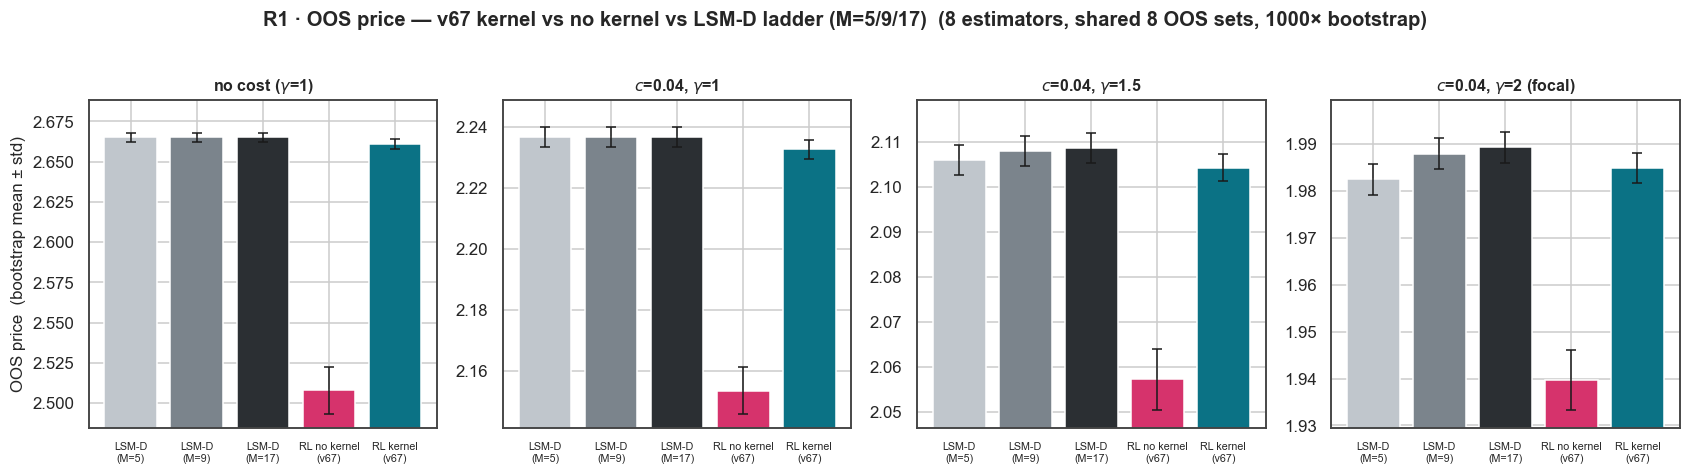

regime,method,Δ% (paired),± std
no cost (γ=1),RL no kernel (v67),-5.888,0.578
no cost (γ=1),RL kernel (v67),-0.161,0.015
"c=0.04, γ=1",RL no kernel (v67),-3.707,0.352
"c=0.04, γ=1",RL kernel (v67),-0.182,0.022
"c=0.04, γ=1.5",RL no kernel (v67),-2.314,0.334
"c=0.04, γ=1.5",RL kernel (v67),-0.082,0.020
"c=0.04, γ=2 (focal)",RL no kernel (v67),-2.159,0.218
"c=0.04, γ=2 (focal)",RL kernel (v67),+0.127,0.036


In [8]:
methods = ["lsm_M5", "lsm_M9", "lsm_M17", "kernel_off", "kernel_on"]
mlabel  = {"lsm_M5": "LSM-D\n(M=5)", "lsm_M9": "LSM-D\n(M=9)", "lsm_M17": "LSM-D\n(M=17)",
           "kernel_off": "RL no kernel\n(v67)", "kernel_on": "RL kernel\n(v67)"}
mcol    = {"lsm_M5": COL["lsm_M5"], "lsm_M9": COL["lsm_M9"], "lsm_M17": COL["lsm_M17"],
           "kernel_off": COL["kernel_off"], "kernel_on": COL["kernel_on"]}
REG_PLAIN = {"nocost": "no cost (γ=1)", "g1": "c=0.04, γ=1", "g15": "c=0.04, γ=1.5", "g2": "c=0.04, γ=2 (focal)"}

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.2))
delta_rows = []
for ax, reg in zip(axes, REG_ORDER):
    piv = RL[RL.regime == reg].pivot_table(index="seed", columns="method", values="price")
    means, errs = zip(*((boot(piv[m].values) if m in piv else (np.nan, np.nan)) for m in methods))
    ax.bar(range(len(methods)), means, color=[mcol[m] for m in methods], edgecolor="white",
           yerr=errs, capsize=3, error_kw=dict(lw=1))
    ax.set_xticks(range(len(methods))); ax.set_xticklabels([mlabel[m] for m in methods], fontsize=7)
    ax.set_title(REG_LABEL[reg], fontsize=10.5)
    fm = [m for m in means if np.isfinite(m)]; fe = [e for e in errs if np.isfinite(e)] or [0.0]
    if fm: ax.set_ylim(min(fm) - max(fe) * 1.6, max(fm) + max(fe) * 1.6)
    for m in ["kernel_off", "kernel_on"]:
        dmu, dse = boot((100 * (piv[m] / piv["lsm_M5"] - 1)).values)
        delta_rows.append({"regime": REG_PLAIN[reg], "method": mlabel[m].replace("\n", " "),
                           "Δ% (paired)": dmu, "± std": dse})
axes[0].set_ylabel("OOS price  (bootstrap mean ± std)")
fig.suptitle("R1 · OOS price — v67 kernel vs no kernel vs LSM-D ladder (M=5/9/17)  "
             "(8 estimators, shared 8 OOS sets, 1000× bootstrap)", fontweight="bold", y=1.02)
fig.tight_layout(); save(fig, "R1_pricing"); plt.show()

dt = pd.DataFrame(delta_rows); V = dt["Δ% (paired)"].abs().max()
display(dt.style.hide(axis="index")
        .format({"Δ% (paired)": "{:+.3f}", "± std": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["Δ% (paired)"], vmin=-V, vmax=V)
        .set_caption("Paired Δ% vs LSM-D (M=5) on the same OOS set — bootstrap mean ± std"))


### R2 · Sample efficiency — v67 kernel vs no kernel

Out-of-sample price vs training budget for both v67 modes (kernel = **accuracy champion**: GELU-β3, actor-32, batch-64, critic-4-layer, learn-4), with full-state LSM-D ($M{=}5$) as the benchmark. Bands are the **1000-resample bootstrap** std over the 8 shared OOS sets; the kernel reaches the LSM level in far fewer episodes than the single-sample no-kernel mode.

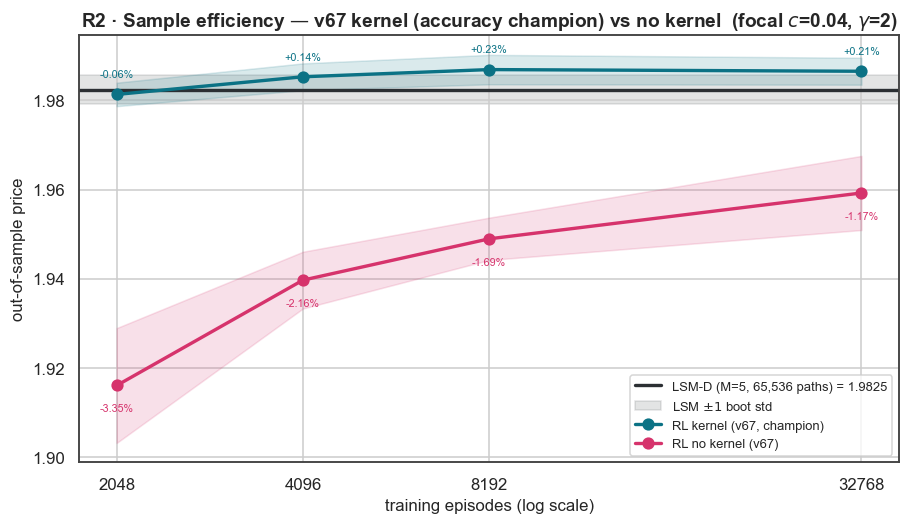

kernel_on   @32768 ep: 1.9866  (+0.21% of LSM-D, boot std 0.0030)
kernel_off  @32768 ep: 1.9592  (-1.17% of LSM-D, boot std 0.0083)


In [9]:
lsm_mu, lsm_se = boot(EE[EE.method == "lsm_M5"].price.values)
N_LSM = 65536

fig, ax = plt.subplots(figsize=(8.4, 4.9))
ax.axhline(lsm_mu, color=COL["lsm_M17"], lw=2.2, zorder=2,
           label=f"LSM-D (M=5, {N_LSM:,} paths) = {lsm_mu:.4f}")
ax.axhspan(lsm_mu - lsm_se, lsm_mu + lsm_se, color=COL["lsm_M17"], alpha=.13, zorder=0,
           label=r"LSM $\pm 1$ boot std")

for method, lbl, dy in [("kernel_on", "RL kernel (v67, champion)", 11),
                        ("kernel_off", "RL no kernel (v67)", -17)]:
    d = EE[EE.method == method]
    eps = sorted(d.episodes.unique())
    mus, ses = zip(*(boot(d[d.episodes == e].price.values) for e in eps))
    mus, ses = np.array(mus), np.array(ses); c = COL[method]
    ax.fill_between(eps, mus - ses, mus + ses, color=c, alpha=.15, zorder=1)
    ax.plot(eps, mus, "o-", color=c, lw=2.2, ms=7, zorder=3, label=lbl)
    for e, mu in zip(eps, mus):
        ax.annotate(f"{100*(mu/lsm_mu-1):+.2f}%", (e, mu), textcoords="offset points",
                    xytext=(0, dy), ha="center", fontsize=7, color=c)

ax.set_xscale("log", base=2); ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(sorted(EE[EE.episodes > 0].episodes.unique()))
ax.set(xlabel="training episodes (log scale)", ylabel="out-of-sample price",
       title="R2 · Sample efficiency — v67 kernel (accuracy champion) vs no kernel  (focal $c$=0.04, $\\gamma$=2)")
ax.legend(frameon=True, loc="lower right", fontsize=8.5)
fig.tight_layout(); save(fig, "R2_episode_efficiency"); plt.show()

for method in ["kernel_on", "kernel_off"]:
    d = EE[EE.method == method]; top = int(d.episodes.max())
    mu, se = boot(d[d.episodes == top].price.values)
    print(f"{method:11s} @{top:>5d} ep: {mu:.4f}  ({100*(mu/lsm_mu-1):+.2f}% of LSM-D, boot std {se:.4f})")

### R3 · Training-seed dispersion (focal $c{=}0.04$, $\gamma{=}2$)

Per-estimator spread across the 8 seeds on the shared OOS sets, **each method at its own budget**: **LSM-D ($M{=}5$)** fit on 65 536 paths per seed and priced on 65 536, **v67 no-kernel** trained 32 768 ep, **v67 kernel** (accuracy champion) trained 4 096 ep. The RL columns show the **paired** Δ% vs LSM-D (same OOS set); the LSM column shows its own fit-to-fit price dispersion. Whiskers summarise the 8 estimators; the printed seed-std is a 1000× bootstrap.

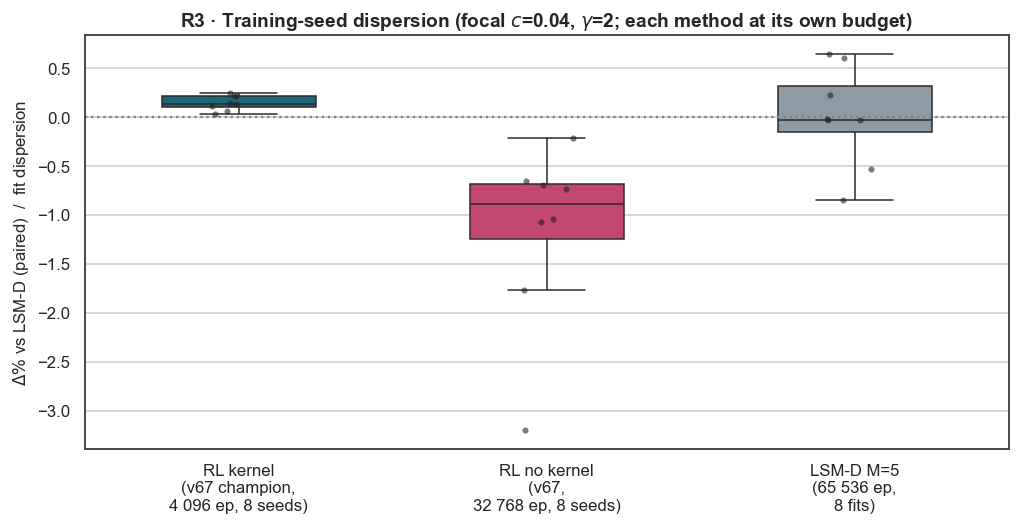

    RL kernel 4k: mean Δ% +0.145 | seed-std 0.077 (boot 0.026)
RL no-kernel 32k: mean Δ% -1.173 | seed-std 0.933 (boot 0.307)
     LSM 65k fit: mean Δ% +0.000 | seed-std 0.511 (boot 0.167)


In [10]:
# R3 reads the focal-g2 episode-efficiency table so each method sits at ITS OWN budget:
#   LSM-D M=5  -> fit/priced on 65 536 paths per seed (episodes = -1 sentinel)
#   no-kernel  -> 32 768 ep      kernel (champion) -> 4 096 ep
lsm  = EE[EE.method == "lsm_M5"].set_index("seed").price
kon  = EE[(EE.method == "kernel_on")  & (EE.episodes == 4096)].set_index("seed").price
koff = EE[(EE.method == "kernel_off") & (EE.episodes == 32768)].set_index("seed").price
idx  = lsm.index.intersection(kon.index).intersection(koff.index)
lsm, kon, koff = lsm.loc[idx], kon.loc[idx], koff.loc[idx]

on  = 100 * (kon  / lsm - 1)
off = 100 * (koff / lsm - 1)
lsm_disp = 100 * (lsm / lsm.mean() - 1)   # LSM fit-to-fit dispersion (training-sample randomness)

LON  = f"RL kernel\n(v67 champion,\n4 096 ep, {len(on)} seeds)"
LOFF = f"RL no kernel\n(v67,\n32 768 ep, {len(off)} seeds)"
LLSM = f"LSM-D M=5\n(65 536 ep,\n{len(lsm_disp)} fits)"
order = [LON, LOFF, LLSM]; pal = {LON: COL["kernel_on"], LOFF: COL["kernel_off"], LLSM: "#8a9ba8"}
dfp = pd.concat([pd.DataFrame({"dpct": on, "grp": LON}),
                 pd.DataFrame({"dpct": off, "grp": LOFF}),
                 pd.DataFrame({"dpct": lsm_disp, "grp": LLSM})], ignore_index=True)

fig, ax = plt.subplots(figsize=(9.4, 4.9))
sns.boxplot(data=dfp, x="grp", y="dpct", order=order, palette=pal, width=.5, fliersize=0, ax=ax)
sns.stripplot(data=dfp, x="grp", y="dpct", order=order, color="#222", size=4, alpha=.6, ax=ax)
ax.axhline(0, ls=":", color="grey")
ax.set(xlabel="", ylabel=r"$\Delta\%$ vs LSM-D (paired)  /  fit dispersion",
       title="R3 · Training-seed dispersion (focal $c$=0.04, $\\gamma$=2; each method at its own budget)")
fig.tight_layout(); save(fig, "R3_seed_robustness"); plt.show()

for lbl, arr in [("RL kernel 4k", on), ("RL no-kernel 32k", off), ("LSM 65k fit", lsm_disp)]:
    mu, se = boot(arr.values)
    print(f"{lbl:>16s}: mean Δ% {mu:+.3f} | seed-std {arr.std(ddof=1):.3f} (boot {se:.3f})")


### R4 · How much of the RL–LSM gap is the action discretisation?

We sweep the LSM action grid $M\in\{2,3,4,5,9,17\}$. **(a)** Discretisation only matters under convex cost ($\gamma>1$); the LSM price is flat in $M$ for no-cost/$\gamma{=}1$. **(b)** RL-kernel tracks even the $M{=}17$ grid; RL no-kernel sits below at every $M$ — the kernel edge is not a discretisation artefact.

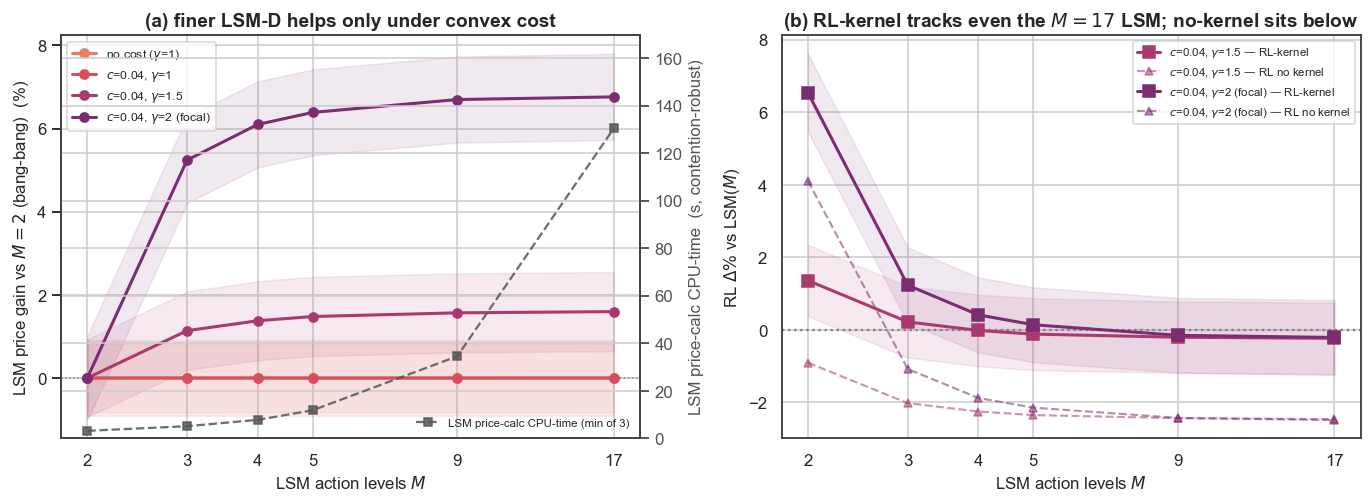

In [11]:
LSMD = pd.read_csv(D / "lsm_discretisation.csv")
MREF = 2  # rebase the price-gain to the coarsest (bang-bang) grid
cmap = dict(zip(REG_ORDER, sns.color_palette("flare", 4)))
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.7))

# (a) LSM relative price gain from finer discretisation, per regime, with 95% CI band
for reg in REG_ORDER:
    s = LSMD[LSMD.regime == reg].sort_values("M")
    base = s[s.M == MREF].price.iloc[0]
    gain = 100*(s.price.values/base - 1)
    band = 100*s.ci95.values/base                     # marginal 95% MC CI in relative units
    ax[0].plot(s.M, gain, "o-", lw=2, color=cmap[reg], label=REG_LABEL[reg], zorder=3)
    ax[0].fill_between(s.M, gain-band, gain+band, color=cmap[reg], alpha=.10, zorder=1)
ax[0].axhline(0, ls=":", color="grey", lw=1)
ax[0].set_xscale("log"); ax[0].set_xticks([2, 3, 4, 5, 9, 17])
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
ax[0].set(xlabel="LSM action levels $M$", ylabel="LSM price gain vs $M{=}2$ (bang-bang)  (%)",
          title="(a) finer LSM-D helps only under convex cost")
ax[0].legend(frameon=True, fontsize=8, loc="upper left")
# secondary axis: price-calculation time vs M (regime-averaged; ~regime-independent)
axt = ax[0].twinx()
tt = LSMD.groupby("M").wall_total.mean().reset_index().sort_values("M")
axt.plot(tt.M, tt.wall_total, "s--", color="#555", lw=1.5, ms=5, alpha=.85, zorder=2,
         label="LSM price-calc CPU-time (min of 3)")
axt.set_ylabel("LSM price-calc CPU-time  (s, contention-robust)", color="#555")
axt.tick_params(axis="y", colors="#555"); axt.set_ylim(0, tt.wall_total.max()*1.3)
axt.legend(frameon=False, fontsize=7.5, loc="lower right")

# (b) both RL variants vs the strengthened LSM at each M (convex regimes, where M matters)
for reg in ["g15", "g2"]:
    g = RL[(RL.regime == reg) & (RL.method == "kernel_on")].groupby("seed").price.first()
    on_mu, on_se = g.mean(), g.std(ddof=1)/np.sqrt(len(g))
    s = LSMD[LSMD.regime == reg].sort_values("M")
    delt = 100*(on_mu/s.price.values - 1)
    se = np.sqrt(on_se**2 + (s.ci95.values/1.96)**2)          # combine RL-seed + LSM MC error
    band = 100*1.96*se/s.price.values
    ax[1].plot(s.M, delt, "s-", lw=2, color=cmap[reg], ms=8,
               label=f"{REG_LABEL[reg]} — RL-kernel", zorder=3)
    ax[1].fill_between(s.M, delt-band, delt+band, color=cmap[reg], alpha=.10, zorder=1)
    nk_mu = RL[(RL.regime == reg) & (RL.method == "kernel_off")].groupby("seed").price.first().mean()
    ax[1].plot(s.M, 100*(nk_mu/s.price.values - 1), "^--", lw=1.4, ms=5, color=cmap[reg],
               alpha=.55, label=f"{REG_LABEL[reg]} — RL no kernel", zorder=2)
ax[1].axhline(0, ls=":", color="grey")
ax[1].set_xscale("log"); ax[1].set_xticks([2, 3, 4, 5, 9, 17])
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
ax[1].set(xlabel="LSM action levels $M$", ylabel=r"RL $\Delta\%$ vs LSM($M$)",
          title="(b) RL-kernel tracks even the $M{=}17$ LSM; no-kernel sits below")
ax[1].legend(frameon=True, fontsize=7.5)
fig.tight_layout(); save(fig, "R4_discretisation"); plt.show()

### R5 · End-to-end role of $M_x$

F2 showed the quadrature target plateaus once $M_x{\ge}2$. Here we confirm the same threshold in the **trained policy's price**: sweeping $M_x\in\{1,2,3,4,6\}$ at 4k episodes, $M_x{=}1$ collapses while $M_x{\ge}2$ is statistically flat.

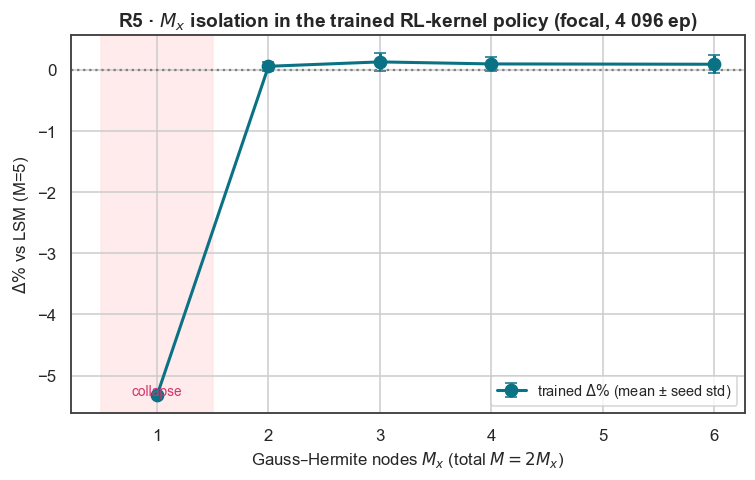

,Δmean (pp),Welch p
comparison,,
M_x=2 vs M_x=1 (collapse threshold),+5.38,0.0e+00
M_x=2 vs M_x=3 (plateau check),-0.07,0.50
M_x=2 vs M_x=4 (plateau check),-0.04,0.63
M_x=2 vs M_x=6 (plateau check),-0.03,0.73
M_x=3 vs M_x=4 (plateau check),+0.03,0.78
M_x=3 vs M_x=6 (plateau check),+0.04,0.77
M_x=4 vs M_x=6 (plateau check),+0.01,0.96


In [12]:
agg = MX.groupby("M_x").delta_pct.agg(["mean", "std", "count"]).reset_index()
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.errorbar(agg.M_x, agg["mean"], yerr=agg["std"], fmt="o-", color=COL["kernel_on"], lw=2,
            capsize=4, ms=8, label=r"trained $\Delta\%$ (mean ± seed std)")
ax.axvspan(0.5, 1.5, color="#ffe3e3", alpha=.7, zorder=0)
ax.text(1.0, agg["mean"].min(), "collapse", ha="center", color=COL["kernel_off"], fontsize=9)
ax.axhline(0, ls=":", color="grey")
ax.set(xlabel=r"Gauss–Hermite nodes $M_x$ (total $M=2M_x$)", ylabel=r"$\Delta\%$ vs LSM (M=5)",
       title="R5 · $M_x$ isolation in the trained RL-kernel policy (focal, 4 096 ep)")
ax.legend(frameon=True)
fig.tight_layout(); save(fig, "R5_mx_isolation"); plt.show()

# --- Compact styled summary ---
import itertools
a1 = MX[MX.M_x == 1].delta_pct.values
a2 = MX[MX.M_x == 2].delta_pct.values
w12 = sa.welch_t_test(a2, a1)

stat_rows = [
    {"comparison": "M_x=2 vs M_x=1  (collapse threshold)",
     "Δmean (pp)": f"{w12['mean_diff']:+.2f}",
     "Welch p": f"{w12['p']:.1e}"},
]
for i, j in itertools.combinations([2, 3, 4, 6], 2):
    wj = sa.welch_t_test(MX[MX.M_x==i].delta_pct.values, MX[MX.M_x==j].delta_pct.values)
    stat_rows.append({
        "comparison": f"M_x={i} vs M_x={j}  (plateau check)",
        "Δmean (pp)": f"{wj['mean_diff']:+.2f}",
        "Welch p": f"{wj['p']:.2f}",
    })

stat_df = pd.DataFrame(stat_rows).set_index("comparison")

def _p_color(v):
    try:
        p = float(v)
    except (ValueError, TypeError):
        return ""
    if p < 0.05:
        return "background-color: #f03e3e; color: white"
    if p < 0.20:
        return "background-color: #ffd43b"
    return "background-color: #2b8a3e; color: white"

display(stat_df.style
    .applymap(_p_color, subset=["Welch p"])
    .set_caption("M_x significance tests — M_x≥2 plateau: all pairwise Welch p > 0.20 (green = n.s.)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-size", "11px"),
                   ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th.row_heading",
         "props": [("text-align", "left"), ("min-width", "260px")]},
    ]))

---
### Summary — headline table and hypothesis tests

In [13]:
g2 = RL[RL.regime == "g2"].pivot_table(index="seed", columns="method", values="price")
rows = []
for m, lbl in [("kernel_on", "RL kernel (v67)"), ("kernel_off", "RL no kernel (v67)")]:
    dp = 100 * (g2[m] / g2["lsm_M5"] - 1)
    dmu, dse = boot(dp.values)
    rows.append({"method": lbl, "n seeds": len(dp), "episodes": 4096,
                 "mean Δ%": dmu, "boot std": dse, "seed std": dp.std(ddof=1),
                 "best Δ%": dp.max(), "worst Δ%": dp.min()})
tbl = pd.DataFrame(rows).set_index("method")
V = float(tbl[["mean Δ%", "best Δ%", "worst Δ%"]].abs().max().max())
display(tbl.round(3).style
    .background_gradient(cmap="RdYlGn", subset=["mean Δ%", "best Δ%", "worst Δ%"], vmin=-V, vmax=V)
    .background_gradient(cmap="RdYlGn_r", subset=["seed std", "boot std"], vmin=0)
    .format({"episodes": "{:,}", "n seeds": "{:.0f}", "mean Δ%": "{:+.3f}", "boot std": "{:.3f}",
             "seed std": "{:.3f}", "best Δ%": "{:+.3f}", "worst Δ%": "{:+.3f}"})
    .set_caption("Focal c=0.04, γ=2 — paired Δ% vs LSM-D (M=5), 1000× bootstrap on 8 shared OOS sets")
    .set_properties(**{"text-align": "center"}))
print(f"v67 kernel − no-kernel gap: {rows[0]['mean Δ%'] - rows[1]['mean Δ%']:+.2f} pp (paired, focal g2)")

,n seeds,episodes,mean Δ%,boot std,seed std,best Δ%,worst Δ%
method,,,,,,,
RL kernel (v67),8,"4,096",+0.127,0.036,0.108,+0.253,-0.015
RL no kernel (v67),8,"4,096",-2.159,0.218,0.649,-1.431,-3.027


v67 kernel − no-kernel gap: +2.29 pp (paired, focal g2)


> **Part II takeaway (v67).** With 8 estimators per method on the same 8 OOS sets and a 1000× bootstrap, the **v67 kernel** mode prices at or above full-state LSM-D across every regime and tracks even the $M{=}17$ LSM grid (R4), while the **v67 no-kernel** mode sits below at the same 4 096-ep budget. The kernel's decisive contribution is **efficiency and stability**: LSM parity in far fewer episodes (R2), tighter seed dispersion (R3), and the $M_x{\ge}2$ threshold from Part I governing the trained outcome end-to-end (R5).

---
#### Reproducibility
RL prices from the **v67 C++ pricer** (`cpp_pricer/build_v67_{kernel,nokernel}`); LSM-D is Python (`src/lsm_swing_pricer`, Chebyshev deg-2, M=5). Part-II CSVs regenerated by `gen_rl_validation_v67.py` (R1/R2, shared OOS sets); Part-I kernel-math CSVs by `gen_kernel_validation.py`, R4 by `gen_r4_discretisation.py`, R5 from `mx_isolation.csv`. Recipes: `cpp_pricer/docs/V61_CONFIG.md`, `docs/research/V61_NOKERNEL_OPTIMIZATION_PLAN.md`.

---
### Full results — every convex-cost cell (Results 8)

The complete $c\times\gamma$ grid (29 cells) under the same v67 methodology: **4 estimators per method on the same 4 OOS 65 536-path sets**, bootstrap mean ± 95% CI (= $1.96\times$ bootstrap SE). The Δ% columns are **paired** vs LSM-D ($M{=}5$) on the identical OOS set. Source: `Convex Costs Results 8.csv` (`gen_results8_v67.py`).

In [14]:
R8 = pd.read_csv(D.parent / "Convex Costs Results 8.csv")

def pm(m, e):
    return m.map("{:.4f}".format) + " ± " + e.map("{:.4f}".format)

disp = pd.DataFrame({
    "c": R8.c, "γ": R8.gamma,
    "LSM-D (M=5)": pm(R8.LSM_mean, R8.LSM_CI95),
    "v67 kernel": pm(R8.KernelOn_mean, R8.KernelOn_CI95),
    "kernel Δ%": R8.KernelOn_Delta_pct,
    "v67 no-kernel": pm(R8.KernelOff_mean, R8.KernelOff_CI95),
    "no-kernel Δ%": R8.KernelOff_Delta_pct,
})
V = float(disp[["kernel Δ%", "no-kernel Δ%"]].abs().max().max())
display(disp.style.hide(axis="index")
        .background_gradient(cmap="RdYlGn", subset=["kernel Δ%", "no-kernel Δ%"], vmin=-V, vmax=V)
        .format({"c": "{:.2f}", "γ": "{:g}", "kernel Δ%": "{:+.2f}", "no-kernel Δ%": "{:+.2f}"})
        .set_caption("Convex Costs Results 8 — LSM-D vs v67 kernel / no-kernel "
                     "(4 seeds, bootstrap mean ± 95% CI; Δ% paired vs LSM-D M=5)"))
print(f"v67 kernel  : mean Δ% {R8.KernelOn_Delta_pct.mean():+.3f} pp over {len(R8)} cells "
      f"(min {R8.KernelOn_Delta_pct.min():+.2f}, max {R8.KernelOn_Delta_pct.max():+.2f})")
print(f"v67 no-kernel: mean Δ% {R8.KernelOff_Delta_pct.mean():+.3f} pp over {len(R8)} cells "
      f"(min {R8.KernelOff_Delta_pct.min():+.2f}, max {R8.KernelOff_Delta_pct.max():+.2f})")


c,γ,LSM-D (M=5),v67 kernel,kernel Δ%,v67 no-kernel,no-kernel Δ%
0.00,1,2.6682 ± 0.0058,2.6632 ± 0.0059,-0.19,2.5071 ± 0.0304,-6.04
0.01,1,2.5558 ± 0.0058,2.5516 ± 0.0053,-0.16,2.4644 ± 0.0254,-3.58
0.01,1.5,2.5144 ± 0.0057,2.5109 ± 0.0052,-0.14,2.4335 ± 0.0101,-3.22
0.01,2,2.4627 ± 0.0055,2.4587 ± 0.0048,-0.16,2.3857 ± 0.0206,-3.13
0.01,3,2.3318 ± 0.0053,2.3319 ± 0.0050,+0.00,2.2798 ± 0.0034,-2.23
0.02,1,2.4474 ± 0.0061,2.4435 ± 0.0060,-0.16,2.3468 ± 0.0099,-4.11
0.02,1.5,2.3709 ± 0.0055,2.3670 ± 0.0059,-0.17,2.2867 ± 0.0205,-3.55
0.02,2,2.2854 ± 0.0054,2.2828 ± 0.0044,-0.11,2.2120 ± 0.0268,-3.21
0.02,3,2.1073 ± 0.0054,2.1158 ± 0.0050,+0.40,2.0573 ± 0.0078,-2.37
0.04,1,2.2402 ± 0.0058,2.2355 ± 0.0060,-0.21,2.1473 ± 0.0289,-4.15


v67 kernel  : mean Δ% +0.671 pp over 29 cells (min -0.24, max +5.16)
v67 no-kernel: mean Δ% -2.575 pp over 29 cells (min -6.04, max +2.11)
